In [ ]:
# ניקוי זיכרון
import gc
import tensorflow as tf

gc.collect()
tf.keras.backend.clear_session()


# Defenition

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from torchsummary import summary
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Preprocessing

In [ ]:

# הגדרות נתונים
train_dir = '/content/drive/MyDrive/Stanford_Cars_dataset-main/train'
test_dir = '/content/drive/MyDrive/Stanford_Cars_dataset-main/test'
image_size = 224
batch_size = 32

# Data Augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0)
])

# טרנספורמציות לבדיקה
test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  std=[0.229, 0.224, 0.225])
])

# ImageFolder
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)



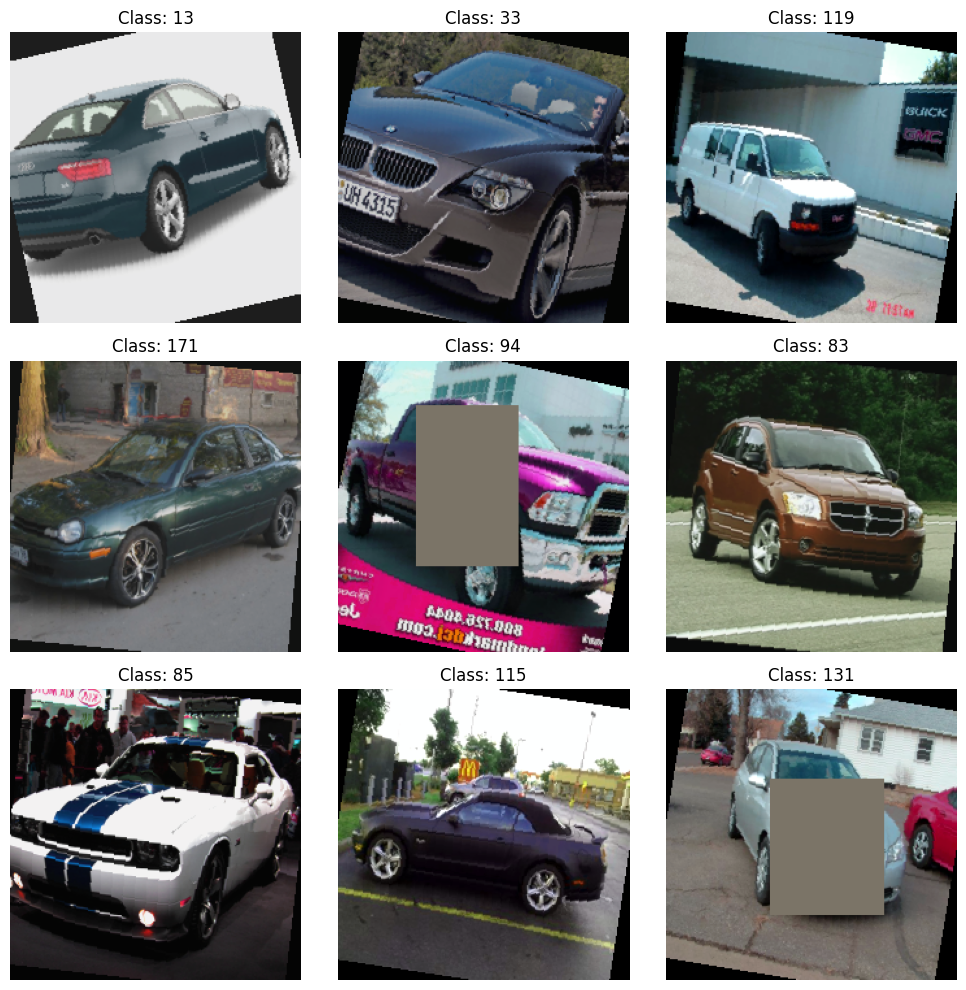

In [ ]:

def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

#
dataiter = iter(train_loader)
images, labels = next(dataiter)

#
n_images = 9
plt.figure(figsize=(10, 10))
for i in range(n_images):
    plt.subplot(3, 3, i+1)
    imshow(images[i])
    plt.title(f"Class: {labels[i]}")
plt.tight_layout()
plt.show()


# Model Architecture

In [ ]:

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            # התאמת ממדים במידה וצריך
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


In [ ]:
class VehicleResNet(nn.Module):
    def __init__(self, num_classes=196):
        super(VehicleResNet, self).__init__()
        # שכבת קונבולוציה ראשונית
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # בניית בלוקים עם חיבורי קיצור
        self.layer1 = self._make_layer(64, 64, blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)

        # Global Average Pooling, Dropout ושכבת Fully Connected
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []

        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# יצירת המודל
model = VehicleResNet(num_classes=196)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VehicleResNet(num_classes=196).to(device)

summary(model, input_size=(3, image_size, image_size))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
    ResidualBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

# Training Strategy 1

In [ ]:

num_epochs = 50
learning_rate = 1e-3
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# משתנים לניהול Early Stopping
best_val_loss = float('inf')
early_stopping_patience = 5
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_accuracy = correct_train / total_train

    # מעבר למצב הערכה ובדיקת ביצועים על סט הבדיקה
    model.eval()
    running_loss_test = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss_test += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_loss = running_loss_test / total_test
    test_accuracy = correct_test / total_test
    scheduler.step(test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

    # בדיקת Early Stopping
    if test_loss < best_val_loss:
        best_val_loss = test_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered.")
            break


Epoch [1/50], Train Loss: 5.3938, Train Acc: 0.0075, Test Loss: 5.4281, Test Acc: 0.0121
Epoch [2/50], Train Loss: 5.2424, Train Acc: 0.0090, Test Loss: 5.1564, Test Acc: 0.0163
Epoch [3/50], Train Loss: 5.2031, Train Acc: 0.0103, Test Loss: 5.1503, Test Acc: 0.0159
Epoch [4/50], Train Loss: 5.1728, Train Acc: 0.0139, Test Loss: 5.1201, Test Acc: 0.0180
Epoch [5/50], Train Loss: 5.1473, Train Acc: 0.0163, Test Loss: 5.1258, Test Acc: 0.0162
Epoch [6/50], Train Loss: 5.1261, Train Acc: 0.0157, Test Loss: 5.0722, Test Acc: 0.0200
Epoch [7/50], Train Loss: 5.0759, Train Acc: 0.0199, Test Loss: 5.1331, Test Acc: 0.0174
Epoch [8/50], Train Loss: 5.0319, Train Acc: 0.0233, Test Loss: 4.9725, Test Acc: 0.0251
Epoch [9/50], Train Loss: 4.9958, Train Acc: 0.0241, Test Loss: 4.9722, Test Acc: 0.0291
Epoch [10/50], Train Loss: 4.9429, Train Acc: 0.0273, Test Loss: 5.0821, Test Acc: 0.0320
Epoch [11/50], Train Loss: 4.8956, Train Acc: 0.0285, Test Loss: 4.8788, Test Acc: 0.0364
Epoch [12/50], Trai

# Training Strategy 2

In [ ]:

num_epochs = 70
learning_rate = 1e-3
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# משתנים לניהול Early Stopping
best_val_loss = float('inf')
early_stopping_patience = 5
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_accuracy = correct_train / total_train

    # מעבר למצב הערכה ובדיקת ביצועים על סט הבדיקה
    model.eval()
    running_loss_test = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss_test += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_loss = running_loss_test / total_test
    test_accuracy = correct_test / total_test
    scheduler.step(test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

    # בדיקת Early Stopping
    if test_loss < best_val_loss:
        best_val_loss = test_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered.")
            break


Epoch [1/70], Train Loss: 5.3635, Train Acc: 0.0074, Test Loss: 5.3684, Test Acc: 0.0099
Epoch [2/70], Train Loss: 5.2320, Train Acc: 0.0096, Test Loss: 6.9695, Test Acc: 0.0083
Epoch [3/70], Train Loss: 5.1986, Train Acc: 0.0108, Test Loss: 5.1533, Test Acc: 0.0159
Epoch [4/70], Train Loss: 5.1632, Train Acc: 0.0118, Test Loss: 5.1616, Test Acc: 0.0138
Epoch [5/70], Train Loss: 5.1269, Train Acc: 0.0168, Test Loss: 5.2276, Test Acc: 0.0143
Epoch [6/70], Train Loss: 5.1003, Train Acc: 0.0168, Test Loss: 5.0923, Test Acc: 0.0177
Epoch [7/70], Train Loss: 5.0702, Train Acc: 0.0177, Test Loss: 5.0854, Test Acc: 0.0224
Epoch [8/70], Train Loss: 5.0396, Train Acc: 0.0173, Test Loss: 4.9803, Test Acc: 0.0218
Epoch [9/70], Train Loss: 5.0125, Train Acc: 0.0220, Test Loss: 4.9788, Test Acc: 0.0260
Epoch [10/70], Train Loss: 4.9507, Train Acc: 0.0235, Test Loss: 5.0463, Test Acc: 0.0223
Epoch [11/70], Train Loss: 4.9157, Train Acc: 0.0274, Test Loss: 4.9363, Test Acc: 0.0313
Epoch [12/70], Trai

# Evaluation 1

In [ ]:


model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

overall_accuracy = accuracy_score(all_labels, all_preds)
print("Final Test Accuracy: {:.2f}%".format(overall_accuracy * 100))
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


Final Test Accuracy: 57.51%
                                                        precision    recall  f1-score   support

                            AM General Hummer SUV 2000       0.85      0.64      0.73        44
                             Acura Integra Type R 2001       0.74      0.39      0.51        44
                                   Acura RL Sedan 2012       0.82      0.56      0.67        32
                                   Acura TL Sedan 2012       0.78      0.81      0.80        43
                                  Acura TL Type-S 2008       0.96      0.52      0.68        42
                                  Acura TSX Sedan 2012       0.58      0.65      0.61        40
                              Acura ZDX Hatchback 2012       0.50      0.49      0.49        39
              Aston Martin V8 Vantage Convertible 2012       0.38      0.27      0.31        45
                    Aston Martin V8 Vantage Coupe 2012       0.42      0.46      0.44        41
           

# Eval 2

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

overall_accuracy = accuracy_score(all_labels, all_preds)
print("Final Test Accuracy: {:.2f}%".format(overall_accuracy * 100))
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


Final Test Accuracy: 67.21%
                                                        precision    recall  f1-score   support

                            AM General Hummer SUV 2000       0.79      0.70      0.75        44
                             Acura Integra Type R 2001       0.74      0.52      0.61        44
                                   Acura RL Sedan 2012       0.66      0.72      0.69        32
                                   Acura TL Sedan 2012       0.73      0.74      0.74        43
                                  Acura TL Type-S 2008       0.89      0.57      0.70        42
                                  Acura TSX Sedan 2012       0.67      0.70      0.68        40
                              Acura ZDX Hatchback 2012       0.67      0.67      0.67        39
              Aston Martin V8 Vantage Convertible 2012       0.46      0.42      0.44        45
                    Aston Martin V8 Vantage Coupe 2012       0.49      0.46      0.47        41
           

In [ ]:
# להוסיף גרפים + דוגמת אימון לא מוצלחת + סיכום על כל החומר במחברת ואיך כל דבר עובד ומדוע בצורה הזאת


In [ ]:
import matplotlib.pyplot as plt

# נניח שיש לנו רשימות:
# train_losses, val_losses, train_accuracies, val_accuracies
# ואורך הרשימות הוא מספר האפוקים

epochs = range(1, len(train_losses) + 1)

# עקומת Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# עקומת Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_accuracies, label='Training Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
